In [1]:

from asyncio import Event
import json
from operator import index
from msilib import Table
from turtle import pd
import streamlit as st
import pandas
import numpy as np
import os
import csv
import tempfile
import shutil
import logging
import re
import unicodedata
import sys
import subprocess
import time
import joblib
import matplotlib.pyplot as plt
import altair as alt

import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta
from tqdm import tqdm
from pathlib import Path
from typing import Iterable, Tuple, List, Set, Dict, Optional, Literal, Union
from collections import Counter
from pathlib import Path
from git import Repo, exc as git_exc

from dataclasses import dataclass
from github import Github, GithubException, UnknownObjectException, IncompletableObject

from CommitExtractorV3 import main as extract_repo_main


sys.path.append('../')
import Settings as cfg
import Utilities as util
import KnowledgeDistribution
import SocialTechnicalNetwork as stn
import ProjectHealthMetrics as phm


def view_df(df, name="DataFrame"):
    ''' Simple HTML table viewer for DataFrames '''
    import tempfile, webbrowser
    html = "\n".join([
        "<meta charset='utf-8'>",
        "<style>body{font-family:system-ui,Segoe UI,Arial}table{border-collapse:collapse}th,td{border:1px solid #ddd;padding:6px}th{position:sticky;top:0;background:#fafafa}</style>",
        f"<h3>{name}</h3>",
        df.to_html(index=False, escape=False),
    ])
    with tempfile.NamedTemporaryFile("w", delete=False, suffix=".html", encoding="utf-8") as f:
        f.write(html)
        webbrowser.open("file://" + f.name)

C:\Users\samut\AppData\Local\Temp\ipykernel_30988\2961014329.py:4: DeprecationWarning: 'msilib' is deprecated and slated for removal in Python 3.13
  from msilib import Table


In [2]:
def load_users_activity(repo_full_name):
    """
    We need to FIND and load all of our raw data
    we have to get the file paths correct
    then we have to load the csv and then put them in a table 

    #insted of just finding the data 
    # we need to have a contiuous data collection system were every day it checks for new data and adds it to the data set
    # so we will have two parts of data collection
    # one algorithm that collects every day
    # one algorithm that gets all of that data
    """
    # in one line find the folder we are in    
    project_root = Path("../")
    orgs_dir = project_root / "Organizations"

    target_files = {
        "issues": cfg.issue_list_file_name,
        "issue_activity": cfg.issue_activity_file_name,
        "prs_repo": cfg.PR_list_file_name,
        "prs_comments": cfg.prs_comments_csv,
        "commit_list": cfg.commit_list_file_name,
        "perfile_commit": cfg.per_file_commits_path
    }
    #we need to make df for each of the target files
    issues = pandas.DataFrame()
    issue_activity = pandas.DataFrame()
    prs_repo = pandas.DataFrame()
    prs_comments = pandas.DataFrame()
    commits = pandas.DataFrame()
    perfile_commits = pandas.DataFrame()

    if not orgs_dir.exists():
        print(f"Organizations folder not found: {orgs_dir}")
        return 0
    
    org, repo = repo_full_name.split('/')
    organization_path = orgs_dir / org

    for repo in organization_path.iterdir():
        if not repo.is_dir():
            continue
        for file_key, file_name in target_files.items():
            file_path = repo / file_name
            if file_path.exists():
                print(f"Found file: {file_path}")
                try:
                    # We need 5 different df that have the new data found appended on to them
                    df = pandas.read_csv(file_path)
                    if file_key == "issues":
                        issues = pandas.concat([issues, df], ignore_index=True)
                    elif file_key == "issue_activity":
                        issue_activity = pandas.concat([issue_activity, df], ignore_index=True)
                    elif file_key == "prs_repo":
                        prs_repo = pandas.concat([prs_repo, df], ignore_index=True)
                    elif file_key == "prs_comments":
                        prs_comments = pandas.concat([prs_comments, df], ignore_index=True)
                    elif file_key == "commit_list":
                        commits = pandas.concat([commits, df], ignore_index=True)
                    elif file_key == "perfile_commit":
                        perfile_commits = pandas.concat([perfile_commits, df], ignore_index=True)
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
            else:
                print(f"File not found: {file_path}")

    raw_data_tables = { "issues": issues, "issue_activity": issue_activity, 
                       "prs_repo": prs_repo, "prs_comments": prs_comments, 
                       "commits": commits , "perfile_commits": perfile_commits}

    #save the data to a temp file
    return raw_data_tables

In [3]:
def label_developers_activity(repo, pbar = Optional[None], user_pbar_percent = Optional[None]) -> pandas.DataFrame:
    """
    main function for labeling developers
    sets up varables to call label timeline
    """
    
    # "../Organizations"
    organizationFolder = cfg.main_folder

    win = cfg.sliding_window_size

    repos_txt = '../' + cfg.repos_file
    repos_to_process = []
        
    
    all_timelines = []
    all_diagnostics = []



    organizationFolder = cfg.main_folder
    organization, project = repo.split('/')
    if Path(organizationFolder, organization).exists() == False:
        st.write(f"Organization folder not found: {Path(organizationFolder, organization)}")

    print(f"Start Identifying inactivity periods for {organization}/{project}...")

    organizationFolder = Path(organizationFolder) / organization / project

    commits =  pandas.read_csv(organizationFolder / "commit_list.csv", parse_dates=["created_at"], encoding="utf-8", header=0, sep=cfg.CSV_separator)

    # this is a json file not a csv file
    tf_devs = pandas.read_json(organizationFolder/ cfg.TF_developers_folder / cfg.TF_developers_file)
    tf_devs = tf_devs.iloc[:, 0].tolist()
    tf= len(tf_devs)
    
    pauses = write_pauses_table(commits, organizationFolder / "pauses_commits.csv", tf_devs, date_col="created_at")
    #make pauses to a csv file at this location C:\Users\samut\OneDrive\Documents\GitHub\developersInactivityAnalysisCOPY\Organizations\Rdatatable\data.table\Results

    print(f"{len(tf_devs)} Developers inactivity periods identified")

    output_folder = organizationFolder /  "Results"
    os.makedirs(output_folder, exist_ok=True)
    count = 0

    for dev in tf_devs:
        print(f"{tf_devs.index(dev) + 1} / {len(tf_devs)}")
        if dev.startswith("author_login") or dev.startswith("author_name") or dev.startswith("author_email"):
            column, dev = dev.split('|')
        count= count+1

        timeline_folder = organizationFolder /  cfg.timeline_folder
        os.makedirs(timeline_folder, exist_ok=True)
            
        timeline_path = Path(timeline_folder, cfg.timeline_file)

        if timeline_path.is_file():
            #our is Timeline created at: ..\Organizations\atom\atom\Timelines\timeline.csv
            user_timeline = pandas.read_csv(timeline_path, sep=cfg.CSV_separator, parse_dates=["date"], index_col="date")
            user_timeline_change = user_timeline[user_timeline["dev"] == dev]
            
        else:
            #we need to make the timeline 
            print(f"Timeline not found at {timeline_path}, generating timeline...")
            continue

        breaks_folder = organizationFolder /  "Breaks"
        os.makedirs(breaks_folder, exist_ok=True)
        breaks_path =  Path(breaks_folder)/  f"{dev}_breaks.csv"              

        #if breaks_path.is_file():
        #    print(breaks_path)
        #    breaks_df = pandas.read_csv(breaks_path, sep=cfg.CSV_separator, index_col=0)  
        #    print(breaks_df)
        #
        #else:
        breaks_df = pandas.DataFrame(columns=['len', 'dates', 'th'])
        #print all input varables
        breaks_df, diagnostics_df = identifyBreaks(pauses, dev=dev, window=win, debug_folder=output_folder)

        breaks_df.to_csv(breaks_path, sep=cfg.CSV_separator, na_rep=cfg.CSV_missing, index=False, lineterminator="\n")
                    
        #add label timeline'
        user_timeline = user_timeline[user_timeline["dev"] == dev]
        user_timeline = label_timeline(user_timeline, breaks_df)

        user_timeline = user_timeline.reset_index()
        all_timelines.append(user_timeline)

        all_diagnostics.append(diagnostics_df)

        out_csv = Path(output_folder) / f"{dev}_labeled_timeline.csv"
        user_timeline.to_csv(out_csv, sep=cfg.CSV_separator, na_rep=cfg.CSV_missing, lineterminator='\n', index_label='date')

        tf_devs_df = pandas.DataFrame(tf_devs, columns=["developer"])
        tf_devs_df.to_csv(Path(output_folder) / "tf_devs.csv", sep=cfg.CSV_separator, na_rep=cfg.CSV_missing, quoting=None, lineterminator='\n')

        # WE NEED TO MAKE A MASTER USER TIMELINE that we use as the return value

    if tf == 1:
        master_user_timeline = all_timelines[0]
        master_diagnostics = all_diagnostics
    else:
        master_user_timeline = pandas.concat(all_timelines, ignore_index=True)
        master_diagnostics = pandas.concat(all_diagnostics, ignore_index=True)


    # append the diagnostics to the time line by joining on the win_end from diagnostics and the dates from timeline
    # master_diagnostics.win_end is object holding datetime.date (needs converting to pandas datetime + normalize).

    # Extract DataFrames from lists if needed
    if isinstance(master_user_timeline, list) and len(master_user_timeline) > 0:
        if isinstance(master_user_timeline[0], pandas.DataFrame):
            master_user_timeline = master_user_timeline[0]

    if isinstance(master_diagnostics, list) and len(master_diagnostics) > 0:
        if isinstance(master_diagnostics[0], pandas.DataFrame):
            master_diagnostics = master_diagnostics[0]

    # Normalize date columns
    master_user_timeline["date"] = pandas.to_datetime(master_user_timeline["date"]).dt.normalize()
    master_diagnostics["date"] = pandas.to_datetime(master_diagnostics["win_end"]).dt.normalize()

    # Merge on dev and date
    master_user_timeline = master_user_timeline.merge(
        master_diagnostics, 
        left_on=["dev", "date"], 
        right_on=["dev", "date"], 
        how="left"
    )

    master_user_timeline.to_csv(Path(output_folder) / "all_users_labeled_timeline.csv", sep=cfg.CSV_separator, na_rep=cfg.CSV_missing, lineterminator='\n', index_label='date')

    # visualize the breaks
    # for each developer in tf_devs we need to make a plot of their timeline with breaks marked
    devs = sorted(master_user_timeline["dev"].unique())

    return master_user_timeline

def write_pauses_table(
        df: pandas.DataFrame,
        out_path: os.PathLike,
        tf_devs: list[str] | None = None,
        *,
        date_col: str = "created_at",
        tail_to_today: bool = True
    ) -> pandas.DataFrame:

    df[date_col] = pandas.to_datetime(df[date_col]).dt.normalize()

    rows = []

    count =0
    for dev in tf_devs:
        if dev.startswith("author_login") or dev.startswith("author_name") or dev.startswith("author_email"):
            column, dev = dev.split('|')
            user_df = df[df[column] == dev]
        else:
            user_df = df[df["author_id"] == dev]
        active_days = sorted(user_df[date_col].dt.date.unique())
        current_row = [dev]

        for i in range(len(active_days) - 1):
            #if we are at the first day then there is no prev day and no period
            # so we skip it
            if i == 0:
                continue
            prev_active_day = active_days[i - 1]
            #FOUND ITTTTTTTT
            current_active_day = active_days[i]
            gap = (current_active_day - prev_active_day).days
            if gap > 1:
                # Inactivity starts the day after prev_active_day
                current_row.append(f"{(prev_active_day + pandas.Timedelta(days=1)).strftime('%Y-%m-%d')}/{(current_active_day - pandas.Timedelta(days=1)).strftime('%Y-%m-%d')}")
            else:
                count += 1

        if tail_to_today:
            today = datetime.now().date()
            gap = (today - active_days[-1]).days
            if gap > 1:
                current_row.append(f"{active_days[-1]}/{today}")
        if len(current_row) > 1:
            rows.append(current_row)
    
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="",encoding="utf-8" ) as f:
        csv.writer(f, delimiter=",", quoting=csv.QUOTE_NONE).writerows(rows)
    out = pandas.DataFrame(rows)

    return out

def label_timeline(user_timeline, breaks_df):
    """
    Make a labled timeline of devlopers breaks

    given a user_timeline and breaks_df
    user_timeline
    dev,date,commits,issues,prs,files_changed,lines_added,lines_removed,prs_review,prs_comment,issues_commented,issues_activity,labeled,closed,commented,mentioned,subscribed,referenced,renamed,issue_type_added,unsubscribed,pinned,locked,reopened,assigned,unlabeled,connected,milestoned,comment_deleted,unassigned,unpinned,demilestoned,marked_as_duplicate,transferred,unmarked_as_duplicate,unlocked,parent_issue_added,parent_issue_removed,sub_issue_added,sub_issue_removed,disconnected
    jekyllbot,2014-06-07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

    breaks_df
    len,dates,th
    72,2015-05-05/2015-07-16,59.25
    """
    df = user_timeline.copy()

    # We need to make coding_day,nc_day 
    # a coding day is something specific
    # coding activity both making a commit to a local repository and opening a pull request
    # that means in daily df commits > 0 AND prs > 0

    # coding activity: commit OR PR
    df["coding_day"] = ((df["commits"] > 0) | (df["prs"] > 0)).astype(int)

    # non-coding activity: any other event > 0 AND no coding
    noncoding_cols = [c for c in df.columns if c in [ "issues", "issue_activity", "pr_activity" ]]
    df["nc_day"] = ((df[noncoding_cols].sum(axis=1) > 0) & (df["coding_day"] == 0)).astype(int)


    df["break_day"] = None
    df["break_day"] = pandas.Series(False, index=df.index, dtype="boolean")
    df["th"] = pandas.Series(pandas.NA, index=df.index, dtype="Float64")
    df["len"] = pandas.Series(pandas.NA, index=df.index, dtype="Int64")
    df["index"] = pandas.Series(pandas.NA, index=df.index, dtype="Int64")

    #this marks the break days from breaks_df onto user_timeline
    for breaks in breaks_df.itertuples():
        start = breaks.dates.split('/')[0]
        end = breaks.dates.split('/')[1]

        start = pandas.to_datetime(start)
        end = pandas.to_datetime(end)

        break_range = pandas.date_range(start=pandas.to_datetime(start),
                                end=pandas.to_datetime(end))

        if pandas.to_datetime(start) <= end:

           for date in break_range:
                date = date.strftime("%Y-%m-%d")
                df.at[date, "break_day"] = True
                df.at[date, "th"] = breaks.th
                df.at[date, "len"] = breaks.len
                df.at[date, "index"] = breaks.Index

    df.index = pandas.to_datetime(df.index)
    df = df.sort_index()

    gone_days = 365

    df["state"] = "ACTIVE"


    # Identify contiguous break windows (groups of consecutive True in break_day)
    bd = df["break_day"]
    group_id = (bd != bd.shift(1)).cumsum()

    df["event_day"] = ((df["coding_day"] >= 1) | (df["nc_day"] >= 1)).astype(int)

    # Precompute last event BEFORE a given date (global, across timeline)
    all_events_idx = df.index[df["event_day"]]

    for gid, block in df.groupby(group_id):

        if not block["break_day"].iloc[0]:
            continue  # not a break chunk

        # This is one contiguous break [start .. end] (inclusive)
        start_ts = block.index[0]
        end_ts   = block.index[-1]


        th_vals = df.loc[start_ts:end_ts, "th"]
        Tfov = int(round(th_vals.iloc[0]))

        # optional: get far-out threshold
        # Anchor silence to the last event (coding or non-coding) before the break starts
        prev_nc_idx = df.index[df["nc_day"] & (df.index < start_ts)]
        last_nc_before = prev_nc_idx.max()

        prev_activity_idx = df.index[df["event_day"] & (df.index < start_ts)]
        last_event_before = prev_activity_idx.max()

        #
        #last_nc = None  # most recent non-coding event inside this break
        #if last_nc_before is not None and (start_ts - last_nc_before).days <= Tfov:
        #    for d in range((start_ts - last_nc_before).days):
        #        current_day = last_nc_before + pandas.Timedelta(days=d + 1)
        #        df.at[current_day, "state"] = "NON_CODING"
        #    print(f"Processing break from {start_ts.date()} to {end_ts.date()} ")
        #    print("last_nc_before", last_nc_before)
        #    print("the most recent day was ", (start_ts - last_nc_before).days, "days ago")
        #    print("Tfov =", Tfov)
        #    view_df(df.loc[start_ts:end_ts], name="Break block before labeling")
        #    print("\n\n")
        

        # Walk day by day inside the break
        for d in block.index:

            # Non-coding event day => NON_CODING and update last_nc
            if bool(df.at[d, "nc_day"]):
                df.at[d, "state"] = "NON_CODING"
                last_nc_before = d
                continue

            # Silent day inside a break -> decide via Tfov and gone
            # Compute silence since the most relevant last event:
            # - Prefer last NC inside break; else use last event before break; else start-of-break as approximate anchor.
            if ((d - last_nc_before).days <= Tfov):
                df.at[d, "state"] = "NON_CODING"
                continue

            # No recent NC: INACTIVE vs GONE (since last ANY event)
            silent_days = (d - last_event_before).days
            if silent_days > gone_days:
                df.at[d, "state"] = "GONE"
            else:
                df.at[d, "state"] = "INACTIVE"
    return df

def getFarOutThreshold(values): ### If it is satisfying, move the function into UTILITIES
    th = 0
    q_3rd = np.percentile(values,75)
    q_1st = np.percentile(values,25)
    iqr = q_3rd-q_1st
    if iqr > 1:
        th = q_3rd + 3*iqr
    return th

def addToBreaksList(current_dt, pauses, intervals_list, currentBreaks, th):
    # we need to find the current pause. this is the current date and the last active day before today 
    # we need to find the previous length of pause
    # we can do this by finding the pause that has the current date as the end date
    # then we can check if the length of that pause is greater than the threshold

    #find the row where current_dt = intervals_list["date"].split('/')[1] or the end date
    for interval in intervals_list:
        int_start_str, int_end_str = interval.split('/')
        if int_end_str != current_dt.strftime('%Y-%m-%d'):
            continue
        else:           
            pause_len = util.daysBetween(int_start_str, int_end_str) + 1
            if int_end_str == current_dt.strftime('%Y-%m-%d') and pause_len >= th:
                # check if this break is already in the list
                if not ((currentBreaks['dates'] == interval).any()):
                    util.add(currentBreaks, [pause_len, interval, th])

    return currentBreaks

def cleanClearBreaks(clearBreaks, breaks):
    for _, b in breaks.iterrows():
        clearBreaks = clearBreaks[clearBreaks.dates != b['dates']] # If it was in the long_breaks list, remove ot from there
    return clearBreaks

def identifyBreaks(pauses_dates_list, dev, window, debug_folder=None):
    '''
    Removes SURE BREAKS from windows to calculate Tfov
    and — with debug_folder — writes a per-window diagnostics CSV.
    '''
    pauses_dates_list = pauses_dates_list.values.tolist()

    breaks_df = pandas.DataFrame(columns=['len', 'dates', 'th'])
    diagnostics = []                             # NEW
    count = 0

    for row in pauses_dates_list:
        # print the first few characters of the row

        if str(row[0]).strip() != str(dev).strip():            # ⬅️  ignore other developers
            continue

        count += 1
        if count % 50 == 0:  # Print progress every 50 rows
            print(count)

        intervals_list = [ x for x in row[1:]
                          if isinstance(x, str) and '/' in x and x.strip()]

        intervals_list.sort(key=lambda s: s.split('/')[0])

        if not all(a.split('/')[0] <= b.split('/')[0]
                for a, b in zip(intervals_list, intervals_list[1:])):
            print("⚠️  intervals_list UNSORTED for", dev[1])

        if not intervals_list:
            print(dev[1], 'has NO valid pauses')
            continue                      # <- don’t bail out; just skip

        clear_breaks = pandas.DataFrame(columns=['len', 'dates'])

        last_th = 0
        if intervals_list:
            FPS_dt = datetime.strptime(intervals_list[0].split('/')[0], '%Y-%m-%d')
            LPE_dt = datetime.strptime(intervals_list[-1].split('/')[1], '%Y-%m-%d')
            print(f"Dev {dev} Start date = {FPS_dt.date()}  End date ={LPE_dt.date()}")
        else:
            print("  (no intervals after filtering)")

        current_dt = FPS_dt
        current_index = 0

        while current_dt < LPE_dt:
            win_start, win_end = current_dt - timedelta(days=window), current_dt
            past_pauses_list = pandas.DataFrame(columns=['len', 'dates'])
            partially_included_pauses_list = pandas.DataFrame(columns=['len', 'dates'])

            for interval in intervals_list:
                int_start_str, int_end_str = interval.split('/')          # keep strings
                int_start_dt  = datetime.strptime(int_start_str, '%Y-%m-%d')
                int_end_dt    = datetime.strptime(int_end_str,   '%Y-%m-%d')
                pause_len = util.daysBetween(int_start_str, int_end_str) + 1
                # fully inside
                if int_start_dt >= win_start and int_end_dt <= win_end:
                    util.add(past_pauses_list, [pause_len, interval])
                # touches boundary but need to still be less than current date
                if ((int_start_dt <= win_end and int_end_dt > win_end and int_end_dt < current_dt) or
                    (int_end_dt >= win_start and int_start_dt < win_start and int_start_dt < current_dt)):
                    util.add(partially_included_pauses_list, [pause_len, interval])
                # we need to add the current pause length to the list of pauses

            
            win_pauses = len(past_pauses_list)
            pauses = pandas.concat([past_pauses_list,
                                    partially_included_pauses_list],
                                    ignore_index=True)

            # --- decision logic (unchanged) ------------------------------
            win_th = None
            added_flag = False
            if win_pauses >= 4:
                # To check if we have look head bias we can look at the
                # data that we are using to calculate the threshold
                #print(pauses)
                win_th = getFarOutThreshold(pauses['len'])
                #print(win_th)
                if win_th > 0:
                    before = len(breaks_df)
                    breaks_df = addToBreaksList( current_dt, pauses, intervals_list, breaks_df, win_th)
                    added_flag = len(breaks_df) > before
                    last_th = win_th
                elif last_th > 0:
                    win_th = last_th
                    before = len(breaks_df)
                    breaks_df = addToBreaksList( current_dt, pauses, intervals_list, breaks_df, last_th)
                    added_flag = len(breaks_df) > before
            else:
            

                if last_th > 0:
                    win_th = last_th
                    before = len(breaks_df)
                    breaks_df = addToBreaksList(current_dt, pauses, intervals_list, breaks_df, last_th)
                    added_flag = len(breaks_df) > before
                else:
                    # If a user is new and doesnt have more than 4 breaks
                    # and they cannot rely on the past breaks to set a threshold
                    # we need to set a very basic threshold
                    # we set it to window size.
                    # meaning if they paused for a length of time equal to 
                    # the entire window we count it as a break
                    win_th = window
                    last_th = win_th
                    before = len(breaks_df)
                    breaks_df = addToBreaksList(current_dt, pauses, intervals_list, breaks_df, win_th)
                    added_flag = len(breaks_df) > before 



            # We need to move to the next acctive day
            # We can find this inside of the pauses list
            current_index += 1
            current_dt = datetime.strptime(intervals_list[current_index].split('/')[1], '%Y-%m-%d') 

            # this is very useful for debugging
            # you can see how each window is decied as a break or not
            diagnostics.append({
                'dev': dev,
                'win_start': win_start.date(),
                'win_end':   win_end.date(),
                'win_pauses': win_pauses,
                'pause_lengths': ';'.join(map(str, pauses['len'].tolist())),
                'partial_lengths': ';'.join(map(str, partially_included_pauses_list['len'].tolist())),
                'win_th': win_th,
                'last_th': last_th,
                'added_as_break': 'yes' if added_flag else 'no'
            })
            # -----------------------------------------------------------------

    diagnostics_df = pandas.DataFrame(diagnostics)

    return breaks_df, diagnostics_df

def timeline(tables, tf_devs, pbar=Optional[None], user_pbar_percent=Optional[None]) -> pandas.DataFrame:
    # given 3 files I need you to count the rows per day per user
    # you are given commits.csv issues.csv prs.csv
    # dev (string; developer id/handle)
    # date (date at daily granularity, e.g., YYYY-MM-DD)
    # commits (non-negative integer)
    # prs (non-negative integer)
    # issues (non-negative integer)
    
    issues = tables['issues']
    commits = tables['commits']
    prs = tables['prs_repo']
    issue_activity = tables['issue_activity']
    pr_activity = tables['prs_comments']

    # Convert created_at columns to datetime
    commits['created_at'] = pandas.to_datetime(commits['created_at'])
    issues['created_at'] = pandas.to_datetime(issues['created_at'])
    prs['created_at'] = pandas.to_datetime(prs['created_at'])
    issue_activity['created_at'] = pandas.to_datetime(issue_activity['created_at'])
    pr_activity['created_at'] = pandas.to_datetime(pr_activity['created_at'])

    # We sometimes do not have a author_id column
    # we add a unique identifier ate the start for the column that we used
    # if it has the string "author_login_" at the start use author_login
    # if it has the strung "author_name_" at the start use author_name
    # if it has the string "author_email_" at the start use author_email
    # if there is nothing at the start we use id

    # Count rows per day per user
    user_activity = []
    for dev in tf_devs:
        print(f"{tf_devs.index(dev) + 1} / {len(tf_devs)}") 
        if dev.startswith("author_login") or dev.startswith("author_name") or dev.startswith("author_email"):
            column, dev = dev.split('|')
            dev_commits = commits[commits[column] == dev]
            dev_issues = issues[issues[column] == dev]
            dev_prs = prs[prs[column] == dev]
        else:
            column = "author_id"
            dev_commits = commits[commits[column] == dev]
            dev_issues = issues[issues[column] == dev]
            dev_prs = prs[prs[column] == dev]
        
        dev_issue_activity = issue_activity[issue_activity[column] == dev]
        dev_pr_activity = pr_activity[pr_activity[column] == dev]

        # Set created_at as index, then resample to daily frequency and count rows
        daily_commits = dev_commits.set_index('created_at').resample('D').size()
        daily_issues = dev_issues.set_index('created_at').resample('D').size()
        daily_prs = dev_prs.set_index('created_at').resample('D').size()
        daily_issue_activity = dev_issue_activity.set_index('created_at').resample('D').size()
        daily_pr_activity = dev_pr_activity.set_index('created_at').resample('D').size()

        # Combine all dates and fill missing values with 0
        all_dates = daily_commits.index.union(daily_issues.index).union(daily_prs.index)
        
        for date in all_dates:
            user_activity.append({
                'dev': dev,
                'date': date.strftime('%Y-%m-%d'),
                'commits': daily_commits.get(date, 0),
                'prs': daily_prs.get(date, 0),
                'issues': daily_issues.get(date, 0),
                'issue_activity': daily_issue_activity.get(date, 0),
                'pr_activity': daily_pr_activity.get(date, 0)
            })

    return pandas.DataFrame(user_activity)


In [4]:

from this import d


STATE_COLORS = {
    "ACTIVE":      (0.85, 0.95, 0.85, 0.6),
    "NON_CODING":  (1.00, 0.95, 0.75, 0.6),
    "INACTIVE":    (1.00, 0.80, 0.80, 0.6),
    "GONE":        (0.90, 0.90, 0.90, 0.6),
}

def developer_timeline_graph(
    user_labeled_timeline: pandas.DataFrame,
    metric_col: str,
    tf_devs: Optional[list] = None):

    if tf_devs is None:
        tf_devs = sorted(user_labeled_timeline["dev"].dropna().unique().tolist())

    figs = {}
    out_dir = Path.cwd()

    for dev in tf_devs:
        df = user_labeled_timeline[user_labeled_timeline["dev"] == dev].copy()

        fig_combined, (ax_activity, ax_metric) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(14, 10),
            sharex=True,
        )

        activty_graph(df, ax=ax_activity)
        metric_graph(df, metric_col, ax=ax_metric)

        fig_combined.tight_layout()

        figs[dev] = {
            "combined": fig_combined,
        }

        out_file = out_dir / f"{dev}_activity_{metric_col}.png"
        fig_combined.savefig(out_file, bbox_inches="tight")
        print(f"Saved {out_file}")
        plt.show()

    return figs

def activty_graph(user_labeled_timeline, ax=None):
    df = user_labeled_timeline.copy()
    df["date"] = pandas.to_datetime(df["date"])
    df = df.sort_values("date")

    df["noncoding_activity"] = df["prs"] + df["commits"]
    df["coding_activity"] = df["issues"] + df["issue_activity"] + df["pr_activity"]

    df["log_noncoding_activity"] = np.log1p(df["noncoding_activity"])
    df["log_coding_activity"] = np.log1p(df["coding_activity"])

    fig = None
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))

    for date, state in zip(df["date"], df["state"]):
        ax.axvspan(
            date,
            date + pandas.Timedelta(days=1),
            color=STATE_COLORS.get(state, (1.0, 1.0, 1.0, 0.0)),
            linewidth=0,
        )

    bar_width = 0.4
    ax.bar(
        df["date"] - pandas.Timedelta(days=0.2),
        df["log_noncoding_activity"],
        width=bar_width,
        label="noncoding_activity (log1p)",
    )
    ax.bar(
        df["date"] + pandas.Timedelta(days=0.2),
        df["log_coding_activity"],
        width=bar_width,
        label="coding_activity (log1p)",
    )

    ax.set_title("Developer activity timeline")
    ax.set_ylabel("log1p(activity)")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left")
    ax.set_xlim(df["date"].min(), df["date"].max() + pandas.Timedelta(days=1))

    if fig is not None:
        fig.autofmt_xdate()
        return fig

    return ax

def metric_graph(user_labeled_timeline, metric_col, ax=None):
    # all i need is a line graph of the metric_col
    df = user_labeled_timeline.copy()
    df["date"] = pandas.to_datetime(df["date"])
    df = df.sort_values("date")

    fig = None
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(df["date"], df[metric_col])
    ax.set_title(f"{metric_col} timeline")
    ax.set_xlabel("date")
    ax.set_ylabel(metric_col)

    if fig is not None:
        fig.autofmt_xdate()
        return fig

    return ax


The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [8]:
def build_metrics(raw_data_tables, user_labeled_timeline, tf_devs):

    dev_weekly_metrics = build_dev_week_activity(raw_data_tables, user_labeled_timeline, tf_devs)

    dev_daily_metrics = build_dev_daily_activity(raw_data_tables, user_labeled_timeline, tf_devs)


    repo_weekly_metrics = build_repo_week_metrics(raw_data_tables, user_labeled_timeline, tf_devs)

    repo_daily_metrics =build_repo_daily_metrics(raw_data_tables, user_labeled_timeline, tf_devs)

    table = {
    "dev_weekly_metrics": dev_weekly_metrics, 
    "dev_daily_metrics": dev_daily_metrics,
    "repo_weekly_metrics": repo_weekly_metrics,
    "repo_daily_metrics": repo_daily_metrics
    }
    return table

def build_dev_week_activity(raw_data_tables, user_labeled_timeline,tf_devs):
    '''
     from prs_repo + prs_comments: compute weekly avg_pr_response_time_hours for each dev
     first_pr_comment_time - pr_open_time
    '''
    out_path = "dev_week_metrics.csv"

    pass

def build_dev_daily_activity(raw_data_tables, user_labeled_timeline, tf_devs):

    pass

def build_repo_week_metrics(raw_data_tables, user_labeled_timeline, tf_devs):
    """
    From prs_repo + prs_comments: compute weekly avg_pr_response_time_hours for each repo.

    Output columns:
      - repo
      - week_start (date, start of week anchored on Monday)
      - n_prs_total
      - n_prs_with_response
      - pr_response_rate
      - avg_pr_response_time_hours
      - median_pr_response_time_hours
      - count_of_commits_per_week
    """

    out_path = "repo_week_metrics.csv"

    pr_df = raw_data_tables["prs_repo"].copy()
    pr_comments_df = raw_data_tables["prs_comments"].copy()

    # --- Parse / normalize types ---
    pr_df["created_at"] = pandas.to_datetime(pr_df["created_at"], utc=True, errors="coerce")
    pr_comments_df["created_at"] = pandas.to_datetime(pr_comments_df["created_at"], utc=True, errors="coerce")

    # author_id is a GitHub GraphQL node id (string), keep it as string
    pr_df["author_id"] = pr_df["author_id"].astype("string")
    pr_comments_df["author_id"] = pr_comments_df["author_id"].astype("string")

    # PR_id sometimes shows up as float in comments; coerce both to Int64
    pr_df["PR_id"] = pandas.to_numeric(pr_df["PR_id"], errors="coerce").astype("Int64")
    pr_comments_df["PR_id"] = pandas.to_numeric(pr_comments_df["PR_id"], errors="coerce").astype("Int64")

    pr_df = pr_df.dropna(subset=["repo", "PR_id", "created_at", "author_id"])
    pr_comments_df = pr_comments_df.dropna(subset=["repo", "PR_id", "created_at", "author_id"])


    # --- Build PR table + comments table for join ---
    prs = pr_df[["repo", "PR_id", "author_id", "created_at"]].rename(
        columns={"author_id": "pr_author_id", "created_at": "pr_created_at"}
    )
    comments = pr_comments_df[["repo", "PR_id", "author_id", "created_at"]].rename(
        columns={"author_id": "comment_author_id", "created_at": "comment_created_at"}
    )

    # --- For each PR, find first EXTERNAL comment (commenter != PR author) ---
    joined = comments.merge(prs, on=["repo", "PR_id"], how="inner")
    joined = joined[joined["comment_author_id"] != joined["pr_author_id"]]

    first_comment = (
        joined.groupby(["repo", "PR_id"], as_index=False)["comment_created_at"]
        .min()
        .merge(prs, on=["repo", "PR_id"], how="left")
    )

    first_comment["response_time_hours"] = (
        (first_comment["comment_created_at"] - first_comment["pr_created_at"])
        .dt.total_seconds()
        / 3600.0
    )

    # guard against weird negatives / nulls
    first_comment = first_comment[
        first_comment["response_time_hours"].notna() & (first_comment["response_time_hours"] >= 0)
    ]

    # --- Week bucketing: week start anchored on Monday, based on PR created time ---
    # NOTE: to_period('W-MON') defines weeks ending on Monday; start_time gives the start of that period.
    first_comment["week_start"] = (
        first_comment["pr_created_at"]
        .dt.to_period("W-MON")
        .apply(lambda p: p.start_time.date())
    )
    prs["week_start"] = prs["pr_created_at"].dt.to_period("W-MON").apply(lambda p: p.start_time.date())

    # --- Aggregate response-time metrics per repo-week ---
    resp_week = first_comment.groupby(["repo", "week_start"], as_index=False).agg(
        avg_pr_response_time_hours=("response_time_hours", "mean"),
        median_pr_response_time_hours=("response_time_hours", "median"),
        n_prs_with_response=("PR_id", "nunique"),
    )

    # --- Total PRs per repo-week (denominator) ---
    pr_week = prs.groupby(["repo", "week_start"], as_index=False).agg(
        n_prs_total=("PR_id", "nunique")
    )

    out = pr_week.merge(resp_week, on=["repo", "week_start"], how="left")

    # Fill count/rate where there were PRs but no external TF-dev comment response
    out["n_prs_with_response"] = out["n_prs_with_response"].fillna(0).astype(int)
    out["pr_response_rate"] = out["n_prs_with_response"] / out["n_prs_total"]


    commits_df= raw_data_tables["commits"].copy()

    commits_df["created_at"] = pandas.to_datetime(commits_df["created_at"], utc=True, errors="coerce")  
    commits_df = commits_df.dropna(subset=["repo", "created_at"])
    commits_df["week_start"] = (
        commits_df["created_at"]
        .dt.to_period("W-MON")
        .apply(lambda p: p.start_time.date())
    )
    commit_counts = (
        commits_df.groupby(["repo", "week_start"], as_index=False).size().rename(columns={"size": "commit_count_per_week"})
    )
    out = out.merge(commit_counts, on=["repo", "week_start"], how="left")
    out["commit_count_per_week"] = out["commit_count_per_week"].fillna(0).astype(int)
    
    out = out.sort_values(["repo", "week_start"]).reset_index(drop=True)

    # Write
    sep = getattr(globals().get("cfg", None), "CSV_separator", ",")
    out.to_csv(out_path, index=False, sep=sep)

    return out

def build_repo_daily_metrics(raw_data_tables, user_labeled_timeline, tf_devs):

    pass

def event_catalog(repo_weekly_metrics, user_labeled_timeline):
    """
    Build a break-event catalog (one row per break episode).

    Uses user_labeled_timeline (daily) to detect break episodes:
      - prefers boolean column 'break_day' if present
      - otherwise uses state in {'INACTIVE','GONE'}

    Merges repo_weekly_metrics at t0_week and computes baseline/during repo metrics.

    Returns: DataFrame written to event_catalog.csv
    """

    out_path = "event_catalog.csv"
    sep = getattr(globals().get("cfg", None), "CSV_separator", ",")

    tl = user_labeled_timeline.copy()
    rw = repo_weekly_metrics.copy()

    # -------------------------
    # Normalize timeline columns
    # -------------------------
    # Ensure we have a date column
    if "date" not in tl.columns:
        print("date not in tl.columns")

    # Identify dev column
    dev_col = "dev" if "dev" in tl.columns else ("author_id" if "author_id" in tl.columns else None)
    if dev_col is None:
        raise ValueError("user_labeled_timeline must contain a developer column named 'dev' or 'author_id'.")

    tl["date"] = pandas.to_datetime(tl["date"], utc=True, errors="coerce")
    tl = tl.dropna(subset=["date", dev_col]).copy()
    tl[dev_col] = tl[dev_col].astype("string")

    # week_start must match your repo_weekly_metrics bucketing (W-MON start_time.date())
    tl["week_start"] = (
        tl["date"].dt.to_period("W-MON").apply(lambda p: p.start_time.date())
    )

    # Determine "is break day"
    if "break_day" in tl.columns:
        bd = tl["break_day"]
        if bd.dtype == bool:
            tl["is_break"] = bd
        else:
            tl["is_break"] = (
                bd.astype("string").str.lower().isin(["true", "1", "t", "yes", "y"])
            )
    else:
        # fall back to state labels
        if "state" not in tl.columns:
            raise ValueError("Need either 'break_day' boolean column or a 'state' column to detect breaks.")
        tl["is_break"] = tl["state"].astype("string").str.upper().isin(["INACTIVE", "GONE"])

    # Repo name (timeline often doesn't have it)
    if "repo" not in tl.columns:
        repos = rw["repo"].dropna().unique()
        tl["repo"] = repos[0] if len(repos) == 1 else None

    # -------------------------
    # Prep weekly dev activity (for baseline/severity)
    # -------------------------
    metric_cols = [c for c in ["commits", "prs", "issues", "issue_activity", "pr_activity", "coding_day", "nc_day"]
                  if c in tl.columns]

    # weekly sums
    if metric_cols:
        weekly_dev = (
            tl.groupby(["repo", dev_col, "week_start"], as_index=False)[metric_cols]
              .sum(numeric_only=True)
        )
    else:
        weekly_dev = tl.groupby(["repo", dev_col, "week_start"], as_index=False).size().rename(columns={"size": "days"})

    # -------------------------
    # Normalize repo_weekly_metrics week_start type
    # -------------------------
    rw = rw.copy()
    rw["week_start"] = pandas.to_datetime(rw["week_start"], errors="coerce").dt.date
    rw = rw.dropna(subset=["repo", "week_start"]).copy()

    # -------------------------
    # Find break episodes per dev
    # -------------------------
    PRE_WEEKS = 4  # baseline window length (weeks)

    events = []
    event_id = 0

    for (repo, dev), g in tl.groupby(["repo", dev_col], dropna=False):
        g = g.sort_values("date").reset_index(drop=True)

        is_break = g["is_break"].fillna(False)
        starts = g.index[(is_break) & (~is_break.shift(1, fill_value=False))].tolist()
        ends   = g.index[(is_break) & (~is_break.shift(-1, fill_value=False))].tolist()

        for s_idx, e_idx in zip(starts, ends):
            event_id += 1

            start_date = g.loc[s_idx, "date"]
            end_date   = g.loc[e_idx, "date"]

            t0_week = g.loc[s_idx, "week_start"]
            break_weeks = set(g.loc[s_idx:e_idx, "week_start"].tolist())

            # t1 = first non-break day after the episode (nullable)
            if e_idx + 1 < len(g):
                t1_date = g.loc[e_idx + 1, "date"]
                t1_week = g.loc[e_idx + 1, "week_start"]
            else:
                t1_date = pandas.NaT
                t1_week = pandas.NA

            break_len_days = int((end_date - start_date).days) + 1
            break_len_weeks = int(len(break_weeks))

            # -------- baseline / during commits (weekly) --------
            baseline_commits = pandas.NA
            during_commits = pandas.NA
            severity_commits = pandas.NA

            if "commits" in metric_cols:
                wd = weekly_dev[(weekly_dev["repo"] == repo) & (weekly_dev[dev_col] == dev)].copy()

                # baseline weeks: [t0_week - PRE_WEEKS, t0_week)
                baseline_start = (pandas.Timestamp(t0_week) - pandas.Timedelta(days=7 * PRE_WEEKS)).date()
                base = wd[(wd["week_start"] >= baseline_start) & (wd["week_start"] < t0_week)]
                dur  = wd[wd["week_start"].isin(break_weeks)]

                if len(base) > 0:
                    baseline_commits = float(base["commits"].mean())
                if len(dur) > 0:
                    during_commits = float(dur["commits"].mean())

                if baseline_commits is not pandas.NA and during_commits is not pandas.NA:
                    severity_commits = float(baseline_commits - during_commits)

            # -------- repo-level metrics baseline/during + t0 merge keys --------
            row = {
                "event_id": event_id,
                "repo": repo,
                "dev": dev,
                "t0_week": t0_week,
                "t1_week": t1_week,
                "break_len_weeks": break_len_weeks,
                "break_len_days": break_len_days,
                "key_dev": True,               # timeline likely already filtered to TF devs
                "truck_rank": pandas.NA,        # placeholder (add later if you have it)
                "baseline_commits": baseline_commits,
                "during_break_commits": during_commits,
                "severity_commits": severity_commits,
            }

            # Add a couple useful onset-day flags if present
            for c in ["state", "event_day", "th", "len", "win_start", "win_end", "win_pauses", "pause_lengths",
                      "partial_lengths", "win_th", "last_th", "added_as_break"]:
                if c in g.columns:
                    row[f"t0_{c}"] = g.loc[s_idx, c]

            events.append(row)

    out = pandas.DataFrame(events)

    # If no events, still write a file with headers
    if out.empty:
        out.to_csv(out_path, index=False, sep=sep)
        return out

    # -------------------------
    # Merge repo_weekly_metrics at t0_week
    # -------------------------
    repo_t0 = rw.rename(columns={c: f"repo_t0_{c}" for c in rw.columns if c not in ["repo", "week_start"]})
    out = out.merge(
        repo_t0,
        left_on=["repo", "t0_week"],
        right_on=["repo", "week_start"],
        how="left",
    ).drop(columns=["week_start"])

    # -------------------------
    # Add baseline/during repo PR-response stats (optional but useful)
    # -------------------------
    rw_by_repo = {r: df.set_index("week_start") for r, df in rw.groupby("repo")}

    def mean_over(repo, weeks, col):
        df = rw_by_repo.get(repo)
        if df is None or col not in df.columns:
            return pandas.NA
        vals = df.reindex(list(weeks))[col]
        vals = vals.dropna()
        return float(vals.mean()) if len(vals) else pandas.NA

    # baseline weeks list per event (same PRE_WEEKS window)
    baseline_cols = ["avg_pr_response_time_hours", "median_pr_response_time_hours", "pr_response_rate", "n_prs_total"]
    for col in baseline_cols:
        base_vals = []
        dur_vals = []
        delta_vals = []
        for _, r in out.iterrows():
            t0 = r["t0_week"]
            base_start = (pandas.Timestamp(t0) - pandas.Timedelta(days=7 * PRE_WEEKS)).date()
            base_weeks = [ (pandas.Timestamp(base_start) + pandas.Timedelta(days=7*i)).date() for i in range(PRE_WEEKS) ]
            # during weeks are not stored, approximate using t0 + break_len_weeks
            dur_weeks = [ (pandas.Timestamp(t0) + pandas.Timedelta(days=7*i)).date() for i in range(int(r["break_len_weeks"])) ]

            b = mean_over(r["repo"], base_weeks, col)
            d = mean_over(r["repo"], dur_weeks, col)
            base_vals.append(b)
            dur_vals.append(d)

            # delta: during - baseline (positive means it got worse for response time)
            if b is pandas.NA or d is pandas.NA:
                delta_vals.append(pandas.NA)
            else:
                delta_vals.append(float(d - b))

        out[f"repo_baseline_{col}"] = base_vals
        out[f"repo_during_{col}"] = dur_vals
        out[f"repo_delta_{col}"] = delta_vals

    out = out.sort_values(["repo", "dev", "t0_week"]).reset_index(drop=True)
    out.to_csv(out_path, index=False, sep=sep)
    return out
    
def stacked_events(event_catalog_df, repo_weekly_metrics, K=8):
    """
    Build stacked event panel:
      - For each event, create k=-K..+K rows
      - calendar_week = t0_week + 7*k days
      - merge repo_weekly_metrics by (repo, week_start)
      - add event-level overlap flags within +/- G weeks (same repo)
    """ 
    out_path="stacked_event_panel.csv"

    G = 8 

    ec = event_catalog_df.copy()
    rw = repo_weekly_metrics.copy()

    # --- normalize week types to date ---
    for col in ["t0_week", "t1_week"]:
        if col in ec.columns:
            ec[col] = pandas.to_datetime(ec[col], errors="coerce").dt.date

    rw["week_start"] = pandas.to_datetime(rw["week_start"], errors="coerce").dt.date

    # --- overlap flags (event-level, same repo) ---
    # overlap = other event in same repo whose t0 is within +/- G weeks of this event's t0
    ec["_t0"] = pandas.to_datetime(ec["t0_week"])
    ec["overlap_other_events_within_G"] = 0

    for repo, grp in ec.groupby("repo"):
        t0s = grp["_t0"].values
        idxs = grp.index.values
        for i, idx in enumerate(idxs):
            window_start = t0s[i] - np.timedelta64(7 * G, "D")
            window_end   = t0s[i] + np.timedelta64(7 * G, "D")
            # count other events in window excluding itself
            count = int(np.sum((t0s >= window_start) & (t0s <= window_end)) - 1)
            ec.loc[idx, "overlap_other_events_within_G"] = count

    ec = ec.drop(columns=["_t0"], errors="ignore")

    # --- expand each event into k rows ---
    rows = []
    for _, r in ec.iterrows():
        t0 = r["t0_week"]
        if pandas.isna(t0):
            continue

        for k in range(-K, K + 1):
            cal_week = (pandas.Timestamp(t0) + pandas.Timedelta(days=7 * k)).date()
            rows.append({
                "event_id": r["event_id"],
                "repo": r["repo"],
                "dev": r.get("dev", pandas.NA),
                "t0_week": t0,
                "calendar_week": cal_week,
                "k": k,
                "post": int(k >= 0),

                # carry event metadata you care about
                "break_len_weeks": r.get("break_len_weeks", pandas.NA),
                "break_len_days": r.get("break_len_days", pandas.NA),
                "key_dev": r.get("key_dev", pandas.NA),
                "severity_commits": r.get("severity_commits", pandas.NA),
                "overlap_other_events_within_G": r.get("overlap_other_events_within_G", 0),
            })

    panel = pandas.DataFrame(rows)
    if panel.empty:
        panel.to_csv(out_path, index=False)
        return panel

    # --- merge metrics by calendar_week ---
    # Note: rename week_start -> calendar_week to merge cleanly
    rw2 = rw.rename(columns={"week_start": "calendar_week"})
    panel = panel.merge(rw2, on=["repo", "calendar_week"], how="left")

    # helpful QA flags
    panel["has_metric"] = panel["n_prs_total"].notna() if "n_prs_total" in panel.columns else panel.iloc[:, 0].notna()

    panel = panel.sort_values(["repo", "event_id", "k"]).reset_index(drop=True)
    panel.to_csv(out_path, index=False)
    return panel

In [10]:
list_of_repos = [
            "Rdatatable/data.table"
        ]

for repo_fullname in list_of_repos:

    print(f"Processing repository: {repo_fullname}")
    
    # file paths setup
    #main
    main_folder = Path(cfg.main_folder) / repo_fullname 
    os.makedirs(main_folder, exist_ok=True)
    # collection data
    collection_folder = main_folder / cfg.collection_folder
    os.makedirs(collection_folder, exist_ok=True)
    # TF_developers_folder
    TF_developers_folder = Path(main_folder, cfg.TF_developers_folder)
    os.makedirs(TF_developers_folder, exist_ok=True)
    # TIMELINE FOLDER
    timeline_folder = main_folder / cfg.timeline_folder
    os.makedirs(timeline_folder, exist_ok=True)
    # LABELED TIMELINE FOLDER
    labeled_timeline_folder = main_folder / cfg.labeled_timeline_folder
    os.makedirs(labeled_timeline_folder, exist_ok=True)
    # social network metrics folder
    social_network_metrics_folder = main_folder / cfg.social_network_metrics_folder
    os.makedirs(social_network_metrics_folder, exist_ok=True)
    #dev health metrics folder
    dev_health_metrics_folder = main_folder / cfg.dev_health_metrics_folder
    os.makedirs(dev_health_metrics_folder, exist_ok=True)
    


    #----------------------
    # Load Data
    #---------------------- 
    print("\n\nStep 1: Loading raw data")
    raw_data_tables = load_users_activity(repo_full_name=repo_fullname)
    #----------------------
    # Truck Factor (FIND DEVS)
    #----------------------
    print("\n\nStep 2: Calculating Truck Factor Devlopers")
    tf, tf_devs, author_map, DOE = KnowledgeDistribution.main(repo_full_name=repo_fullname, tables=raw_data_tables)
    # tf_devs is a list of developers
    
    path = Path(TF_developers_folder, cfg.TF_developers_file)
    with open(path, "w") as f:
        json.dump(tf_devs, f)
    
    #----------------------
    # Basic Timeline 
    #----------------------
    print("\n\nStep 3: Generating Basic Timeline")
    out = timeline(raw_data_tables, tf_devs )
    out.to_csv(Path(timeline_folder, cfg.timeline_file), sep=cfg.CSV_separator)
    print(f"Generated basic timeline data.")
    
    #----------------------
    # Label Timeline
    #----------------------
    print("\n\nStep 4: Labeling Developer Activity Timeline")
    user_labeled_timeline = label_developers_activity(repo=repo_fullname)
    #plot timeline
    print(f"Generated labeled timeline data.")
    # save the data to a csv file'
    user_labeled_timeline.to_csv("test.csv", sep=cfg.CSV_separator)


    #-----------------------
    #Project Health Metrics
    #----------------------

    print("\n\nStep 5: Calculating Project Health Metrics")
    dev_summary_df = []
    
    for dev in tf_devs:
        tables = {"user_labeled_timeline": user_labeled_timeline,
                "commits": raw_data_tables['commits'],
                "perfile_commits": raw_data_tables['perfile_commits'],
                "issues": raw_data_tables['issues'],
                "issue_activity": raw_data_tables['issue_activity'],
                "prs_repo": raw_data_tables['prs_repo'],
                "prs_comments": raw_data_tables['prs_comments'],
                "author_map" : author_map,
                "df_DOE" : DOE
                }
        dev_summary_df, folder_summary_df, dev_health_metrics  = phm.main(repo_full_name=repo_fullname, tables=tables, dev_leaving=dev)
        #save each dev summary in dev_summary_df
            #
        dev_health_metrics_path = Path(dev_health_metrics_folder, f"{dev}_{cfg.dev_health_metrics}")
        folder_summary_path = Path(dev_health_metrics_folder, f"{dev}_{cfg.folder_summary_df}")
        dev_summary_path = Path(dev_health_metrics_folder, f"{dev}_{cfg.dev_summary_df}")

        dev_summary_df.to_csv(dev_health_metrics_path, sep=cfg.CSV_separator)
        folder_summary_df.to_csv(folder_summary_path, sep=cfg.CSV_separator)
        dev_health_metrics.to_csv(dev_summary_path, sep=cfg.CSV_separator)
    #----------------------
    #Developer Metrics
    #----------------------

    print("\n\nStep 6: Developer and Repo Weekly and Daily Metrics")

    metrics = build_metrics(raw_data_tables, user_labeled_timeline, tf_devs)
    

    #----------------------
    # event catalog
    #----------------------
    print("\n\nStep 7: event_catalog")

    #graph = developer_timeline_graph(user_labeled_timeline,metric_col= "commits" )

    event_catalog_df = event_catalog(metrics["repo_weekly_metrics"] , user_labeled_timeline)

    #----------------------
    # Stacked event panel builder
    #---------------------- 
    print("\n\nStep 8: stacked_events")
    K = 8
    
    stacked_panel = stacked_events(event_catalog_df, metrics["repo_weekly_metrics"], K)

    view_df(stacked_panel, name="stacked_panel")

    tmp = (stacked_panel
       .dropna(subset=["avg_pr_response_time_hours"])
       .groupby("k", as_index=False)["avg_pr_response_time_hours"]
       .mean())

    print(tmp)

    tmp = (stacked_panel
       .dropna(subset=["commit_count_per_week"])
       .groupby("k", as_index=False)["commit_count_per_week"]
       .mean())
    print(tmp)






Processing repository: Rdatatable/data.table


Step 1: Loading raw data
Found file: ..\Organizations\Rdatatable\data.table\issues.csv
Found file: ..\Organizations\Rdatatable\data.table\issue_activity.csv
Found file: ..\Organizations\Rdatatable\data.table\prs_repo.csv
Found file: ..\Organizations\Rdatatable\data.table\prs_comments.csv
Found file: ..\Organizations\Rdatatable\data.table\commit_list.csv
Found file: ..\Organizations\Rdatatable\data.table\per_file_commits.csv


Step 2: Calculating Truck Factor Devlopers

Processing 18194 file changes across 160 developers

Metrics calculated for 2995 developer-file pairs:
  - 160 unique developers
  - 645 unique files
  - 645 file creators identified

Truck Factor for Rdatatable/data.table: ['MDQ6VXNlcjI3Nzk5OTg=', 'MDQ6VXNlcjc2MDYzODk=', 'MDQ6VXNlcjMxMDIwNDU=']


Step 3: Generating Basic Timeline
1 / 3
2 / 3
3 / 3
Generated basic timeline data.


Step 4: Labeling Developer Activity Timeline
Start Identifying inactivity periods for Rdatatabl

In [19]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.DataFrame({
    "k": [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8],
    "avg_pr_response_time_hours": [423.432344,644.834892,764.271029,1099.498686,312.944002,
                                  858.015175,847.926759,133.566072,1224.552009,1895.162369,
                                  519.187754,1356.363874,1918.065569,1834.215385,1845.302932,
                                  1367.622407,2388.918238]
})
df["avg_pr_response_time_days"] = df["avg_pr_response_time_hours"] / 24.0

# windows
window_pre  = df[df["k"] <= 0].copy()
window_post = df[df["k"] > 0].copy()

mean_pre  = window_pre["avg_pr_response_time_days"].mean()
mean_post = window_post["avg_pr_response_time_days"].mean()
print("mean_pre_days:", mean_pre)
print("mean_post_days:", mean_post)

# lm-style regressions
lm_pre  = smf.ols("avg_pr_response_time_days ~ k", data=window_pre).fit()
lm_post = smf.ols("avg_pr_response_time_days ~ k", data=window_post).fit()

print("\n--- PRE MODEL ---")
print(lm_pre.summary())
print("\n--- POST MODEL ---")
print(lm_post.summary())

# prediction grids for smooth lines
x_pre  = np.linspace(window_pre["k"].min(),  window_pre["k"].max(), 200)
x_post = np.linspace(window_post["k"].min(), window_post["k"].max(), 200)

y_pre  = lm_pre.predict(pd.DataFrame({"k": x_pre}))
y_post = lm_post.predict(pd.DataFrame({"k": x_post}))




mean_pre_days: 29.208522999999996
mean_post_days: 68.35853399999999

--- PRE MODEL ---
                                OLS Regression Results                               
Dep. Variable:     avg_pr_response_time_days   R-squared:                       0.041
Model:                                   OLS   Adj. R-squared:                 -0.096
Method:                        Least Squares   F-statistic:                    0.2993
Date:                       Thu, 29 Jan 2026   Prob (F-statistic):              0.601
Time:                               09:25:28   Log-Likelihood:                -36.421
No. Observations:                          9   AIC:                             76.84
Df Residuals:                              7   BIC:                             77.24
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t

In [20]:


df = pandas.DataFrame({
    "k": [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8],
    "commits_per_week": [10.369565,12.600000,11.731707,11.536585,10.878049, 9.813953, 9.232558,12.046512, 9.951220, 4.512821, 5.675676, 7.228571, 7.512821, 6.833333,10.083333, 8.416667, 6.275000]
})
df["commits_per_day"] = df["commits_per_week"]  / 7.0

# windows
window_pre  = df[df["k"] <= 0].copy()
window_post = df[df["k"] > 0].copy()

mean_pre  = window_pre["commits_per_day"].mean()
mean_post = window_post["commits_per_day"].mean()
print("mean_pre_days:", mean_pre)
print("mean_post_days:", mean_post)

# lm-style regressions
lm_pre  = smf.ols("commits_per_day ~ k", data=window_pre).fit()
lm_post = smf.ols("commits_per_day ~ k", data=window_post).fit()

print("\n--- PRE MODEL ---")
print(lm_pre.summary())
print("\n--- POST MODEL ---")
print(lm_post.summary())

# prediction grids for smooth lines
x_pre  = np.linspace(window_pre["k"].min(),  window_pre["k"].max(), 200)
x_post = np.linspace(window_post["k"].min(), window_post["k"].max(), 200)

y_pre  = lm_pre.predict(pd.DataFrame({"k": x_pre}))
y_post = lm_post.predict(pd.DataFrame({"k": x_post}))



mean_pre_days: 1.5580976031746028
mean_post_days: 1.0096111071428573

--- PRE MODEL ---
                            OLS Regression Results                            
Dep. Variable:        commits_per_day   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1.347
Date:                Thu, 29 Jan 2026   Prob (F-statistic):              0.284
Time:                        09:25:30   Log-Likelihood:                 4.8654
No. Observations:                   9   AIC:                            -5.731
Df Residuals:                       7   BIC:                            -5.336
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

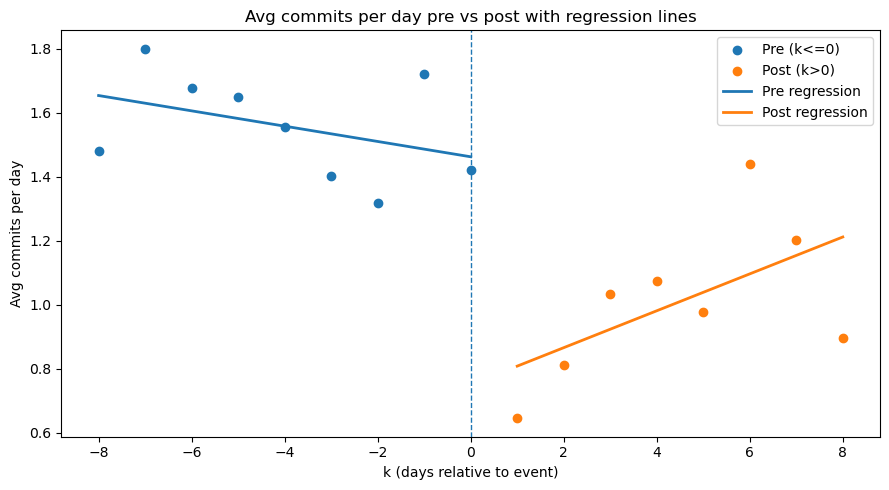

In [21]:
# plot
plt.figure(figsize=(9,5))
plt.scatter(window_pre["k"],  window_pre["commits_per_day"],  label="Pre (k<=0)")
plt.scatter(window_post["k"], window_post["commits_per_day"], label="Post (k>0)")

plt.plot(x_pre,  y_pre,  linewidth=2, label="Pre regression")
plt.plot(x_post, y_post, linewidth=2, label="Post regression")

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("k (days relative to event)")
plt.ylabel("Avg commits per day")
plt.title("Avg commits per day pre vs post with regression lines")
plt.legend()
plt.tight_layout()

plt.show()

# Data Collection

In [ ]:
#   conda activate osslab
#   python CommitExtractorV3.py
### IMPORT EXCEPTION MODULES
import uuid
from requests.exceptions import Timeout
from github import GithubException, UnknownObjectException, IncompletableObject

### IMPORT SYSTEM MODULES
from github import Github
import os, logging, pandas, csv, tempfile, shutil, functools
from datetime import datetime, timezone
from tqdm import tqdm, tqdm
from pathlib import Path
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import signal, threading
import json
from contextlib import contextmanager
from dateutil import tz as _tz
from collections import Counter

### IMPORT CUSTOM MODULES
import sys
sys.path.append('../')
import Settings as cfg
import Utilities as util
from pathlib import Path
import subprocess, tempfile, shutil, logging
from truckfactor.compute import main as compute_tf
import portalocker              # pip install portalocker
import warnings

from dataclasses import dataclass

warnings.filterwarnings("ignore")
from git import Repo, exc as git_exc

### DEFINE CONSTANTS
COMPLETE = "COMPLETE"
STOP_EVENT = threading.Event()

def updateAlldata(organizationFolder, organization, project, full_extraction):
    repo_full_name = f"{organization}/{project}"
    #output
    commits_csv        = cfg.commit_list_file_name
    prs_csv            = cfg.PR_list_file_name
    prs_comments_csv   = cfg.prs_comments_csv
    issues_csv         = cfg.issue_list_file_name
    issue_activity_csv = cfg.issue_activity_file_name
    per_file_commits_path = cfg.per_file_commits_path


    #TODO: excluded repos
    excluded_path = Path(organizationFolder, cfg.excluded_csv)


    # data collected
    commit_cols = ["repo", "created_at", "author_id", "author_name", "author_login", "author_email",  "committer_id",
                   "sha", "filename_list", "fileschanged_count", "additions_sum", "deletions_sum", ]
    
    pr_cols     = ["repo", "created_at", "author_id", "author_name", "author_login", "author_email", "PR_id",
                   "state", "merged", "closed_at", "merged_at"]
                
    prcom_cols  = ["repo", "created_at", "author_id", "author_name", "author_login", "author_email", "PR_id",
                   "comment_id", "event"]

    issue_cols  = ["repo", "created_at", "author_id", "author_name", "author_login", "author_email", "issue_number", "title",
                   "state", "closed_at", "labels", "assignees", "milestone"]

    issue_activity_cols = ["repo", "created_at", "author_id", "author_name", "author_login", "author_email", "issue_number", 
                           "activity_id", "item_type", "event", "body"]

    excluded_cols = ["source_file", "error_id", "additional_info"]

    per_file_commit_columns=["repo", "author_id", "author_login","author_name","author_email","sha", "committed_at", "committer_login",
            "file_path","status","additions","deletions","changes","previous_filename"]
    

    # check what data needs to be extracted and collected.

    #cursor
    cursor_path = Path(organizationFolder,  cfg.data_cursor)

    if cursor_path.exists():
        with open(cursor_path, "r", encoding="utf-8") as f:
            states = json.load(f)

        now = datetime.now(timezone.utc)

        ts = states.get("updated_at").replace("Z", "+00:00")
        updated_at_dt = datetime.fromisoformat(ts)

        max_age = timedelta(days=1)

        # Decide which streams matter for this call
        requested_streams = (
            ["issues_with_timeline", "prs_with_comments", "commits"]
            if full_extraction else
            ["commits"]
        )

        # If we have a timestamp and it's fresh AND all requested streams are complete => skip
        if updated_at_dt is not None:
            age = now - updated_at_dt
            all_done = all(states["streams"][s].get("complete", False) for s in requested_streams)

            if age < max_age and all_done:
                print("Data < 1 day old and requested streams complete — skipping.")
                return

            # If stale (>= 1 day), reopen requested streams so they can collect new stuff
            if age >= max_age:
                for s in requested_streams:
                    states["streams"][s]["complete"] = False
                # IMPORTANT: save the cursor changes
                states["updated_at"] = now.isoformat()
                with open(cursor_path, "w", encoding="utf-8") as f:
                    json.dump(states, f, indent=2)

        else:
            # If missing updated_at, treat as stale: reopen and save
            for s in requested_streams:
                states["streams"][s]["complete"] = False
            states["updated_at"] = now.isoformat()
            with open(cursor_path, "w", encoding="utf-8") as f:
                json.dump(states, f, indent=2)

                

        commits_df      = (pandas.read_csv(Path(organizationFolder, commits_csv), sep=cfg.CSV_separator)
                       if Path(organizationFolder, commits_csv).exists()
                       else pandas.DataFrame(columns=commit_cols))
        
        per_file_commits_df = (pandas.read_csv(Path(organizationFolder, per_file_commits_path), sep=cfg.CSV_separator)
                               if Path(organizationFolder, per_file_commits_path).exists()
                               else pandas.DataFrame(columns=per_file_commit_columns))

        prs_df          = (pandas.read_csv(Path(organizationFolder, prs_csv),
                                    sep=cfg.CSV_separator)
                        if Path(organizationFolder, prs_csv).exists()
                        else pandas.DataFrame(columns=pr_cols))
        
        prs_comments_df = (pandas.read_csv(Path(organizationFolder, prs_comments_csv),
                                    sep=cfg.CSV_separator)
                        if Path(organizationFolder, prs_comments_csv).exists()
                        else pandas.DataFrame(columns=prcom_cols))
        
        issues_df       = (pandas.read_csv(Path(organizationFolder, issues_csv), 
                                    sep=cfg.CSV_separator)
                        if Path(organizationFolder, issues_csv).exists()
                        else pandas.DataFrame(columns=issue_cols))

        issue_activity_df = (pandas.read_csv(Path(organizationFolder, issue_activity_csv),
                                    sep=cfg.CSV_separator)
                        if Path(organizationFolder, issue_activity_csv).exists()
                        else pandas.DataFrame(columns=issue_activity_cols))


    else:
        # we need to make the json file and set it all to zero
        states = {
          "repo": repo_full_name,
          "updated_at": datetime.now(timezone.utc).isoformat(),
          "streams": {
            "issues_with_timeline": { "after": None, "processed": 0, "total": None, "complete": False },
            "prs_with_comments": { "after": None, "processed": 0, "total": None, "complete": False },
            "commits": { "after": None, "processed": 0, "total": None, "complete": False }
          },
          "meta": {
            "last_error": None,
            "last_rate_limit_reset": None
          }
        }
        # we need to make the csv files too
        util.ensure_csv(Path(organizationFolder, commits_csv), columns=commit_cols, sep=cfg.CSV_separator)
        util.ensure_csv(Path(organizationFolder, prs_csv), columns=pr_cols, sep=cfg.CSV_separator)
        util.ensure_csv(Path(organizationFolder, prs_comments_csv), columns=prcom_cols, sep=cfg.CSV_separator)
        util.ensure_csv(Path(organizationFolder, issues_csv), columns=issue_cols, sep=cfg.CSV_separator)
        util.ensure_csv(Path(organizationFolder, issue_activity_csv), columns=issue_activity_cols, sep=cfg.CSV_separator)
        util.ensure_csv(excluded_path, columns=excluded_cols, sep=cfg.CSV_separator)
        util.ensure_csv(Path(organizationFolder, per_file_commits_path), columns=per_file_commit_columns, sep=cfg.CSV_separator)
        commits_df      = pandas.DataFrame(columns=commit_cols)
        prs_df          = pandas.DataFrame(columns=pr_cols)
        prs_comments_df = pandas.DataFrame(columns=prcom_cols)
        issues_df       = pandas.DataFrame(columns=issue_cols)
        issue_activity_df = pandas.DataFrame(columns=issue_activity_cols)
        per_file_commits_df = pandas.DataFrame(columns=per_file_commit_columns)
        # excluded df
        excluded_df     = pandas.DataFrame(columns=excluded_cols)
        #makes the new blank json file 
        util.save_json(states, cursor_path, type= "data_cursor")


    if full_extraction == True:
        work_orders = [
            {"kind": "Issue", "token_idx": 1, "state":  states["streams"]["issues_with_timeline"]},
            {"kind": "PR"   , "token_idx": 2, "state":  states["streams"]["prs_with_comments"]},
            {"kind": "Commit", "token_idx": 0, "state":  states["streams"]["commits"]},
        ]
    else:
        work_orders = [
            {"kind": "Commit", "token_idx": 2, "state":  states["streams"]["commits"]}
        ]


    tables = { "issues": issues_df, "issue_activity": issue_activity_df, "prs_repo": prs_df, "prs_comments": prs_comments_df, "commits": commits_df }

    with ThreadPoolExecutor(max_workers=len(work_orders)) as pool:
        futures = [pool.submit(extraction_worker, order, tables, repo_full_name, organizationFolder)
                for order in work_orders]
        # surface exceptions
        for fut in as_completed(futures):
            fut.result()

def extraction_worker(order, tables, repo_full_name, organizationFolder):
    # This function will be run in a separate thread for each work order
    # It will handle the extraction of data for a specific kind of entity (issue, PR, commit)
    # and write the results to the appropriate CSV files

    token = util.getSpisificToken(order["token_idx"])
    g = Github(token)
    g.per_page = cfg.items_per_page

    if order["kind"] == "Issue":
        return updateIssueListFile(g, token, repo_full_name, organizationFolder, order, tables)
    if order["kind"] == "PR":
        return updatePRListFile(g, token, repo_full_name, organizationFolder, order, tables)
    if order["kind"] == "Commit":
        return updateCommitListFile(g, token, repo_full_name, organizationFolder, order, tables)

    return None

def updateIssueListFile(g, token, repo_full_name: str, organizationFolder: str, order, tables=None):
    """
    Single-worker durable-cursor extractor:
    - Writes issues metadata to `issues.csv` (1 row/issue)
    - Writes ALL activity traces (events + comments + cross-refs) to `issue_activity.csv` from the Timeline API
      Columns: repo, issue_number, activity_id, item_type, event, body, created_at, actor
    """
    if order["state"]["complete"] :     
        return
    
    issues_csv = cfg.issue_list_file_name 
    activity_csv = cfg.issue_activity_file_name

    out_dir = Path(organizationFolder)
    out_dir.mkdir(parents=True, exist_ok=True)
    data_cursor_path = Path(organizationFolder, cfg.data_cursor)

    repo = g.get_repo(repo_full_name)
    owner, name = repo.owner.login, repo.name
    requester = getattr(repo, "requester", None) or getattr(repo, "_requester", None)

    # Ensure CSVs exist with headers
    
    base_variables={"owner": owner, "name": name}
    issue_query = """
    query($owner:String!, $name:String!, $first:Int!, $after:String) {
      repository(owner:$owner, name:$name) {
        issues(states:[OPEN, CLOSED], first:$first, after:$after, orderBy:{field:CREATED_AT, direction:ASC}) {
          totalCount
          pageInfo { hasNextPage endCursor }
          nodes {
            number
            title
            state
            createdAt
            closedAt
            author { 
              login
              ... on User { 
                id
                name
                email
              }
            }
            labels(first:20) { nodes { name } }
            assignees(first:10) { 
              nodes { 
                id
                login 
              } 
            }
            milestone { title }
          }
        }
      }
    }"""

    issue_connection_path = ("data","repository","issues")

    issue_timeline_query = """
    query($owner:String!, $name:String!, $number:Int!, $first:Int!, $after:String) {
      repository(owner:$owner, name:$name) {
        issue(number:$number) {
          timelineItems(first:$first, after:$after) {
            pageInfo { hasNextPage endCursor }
            nodes {
              __typename
              ... on IssueComment {
                id
                createdAt
                author { 
                  login
                  ... on User { 
                    id
                    name
                    email
                  }
                }
                bodyText
              }
              ... on ClosedEvent {
                id
                createdAt
                actor { 
                  login
                  ... on User { 
                    id
                    name
                    email
                  }
                }
              }
              ... on ReopenedEvent {
                id
                createdAt
                actor { 
                  login
                  ... on User { 
                    id
                    name
                    email
                  }
                }
              }
              ... on LabeledEvent {
                id
                createdAt
                actor { 
                  login
                  ... on User { 
                    id
                    name
                    email
                  }
                }
                label { name }
              }
              ... on UnlabeledEvent {
                id
                createdAt
                actor { 
                  login
                  ... on User { 
                    id
                    name
                    email
                  }
                }
                label { name }
              }
              ... on CrossReferencedEvent {
                id
                createdAt
                actor { 
                  login
                  ... on User { 
                    id
                    name
                    email
                  }
                }
              }
            }
          }
        }
      }
    }"""

    per_page= cfg.items_per_page
    # We need to look at the state file which can tell us about
    # the current progress of this extraction
    # we need to check two things 
    # 1. if the extraction is already complete
    # 2. if not complete where did we leave off

    after = order["state"]["after"]

    # ---------- set pbar.total from totalCount (once) ----------
    total_count_query = """
    query($owner:String!, $name:String!) {
      repository(owner:$owner, name:$name) {
        issues(states:[OPEN, CLOSED]) { totalCount }
      }
    }"""
    _, total_d = requester.graphql_query(query=total_count_query, variables={"owner": owner, "name": name})
    total_issues = total_d["data"]["repository"]["issues"]["totalCount"]
    order["state"]["total"] = order["state"]["total"] or int(total_issues)
    
    util.save_json(order["state"], data_cursor_path, type= "issues_with_timeline")
    pbar_issue = tqdm(total=total_issues, desc="Issues", position=0, leave=True)
    pbar_issue.update(order["state"]["processed"])
    #PBAR done
    
    per_page = cfg.items_per_page

    while True:
        vars_page = {"owner": owner, "name": name, "first": per_page, "after": after}
        _, issue_data = requester.graphql_query(query=issue_query, variables=vars_page)

        # walk to connection dict
        issue_conn = issue_data
        for key in issue_connection_path:
            issue_conn = issue_conn[key]

        nodes = issue_conn.get("nodes", []) or []
        page_info = issue_conn["pageInfo"]

        # ---- write issues rows ----
        issue_rows = []
        for nd in nodes:
            
            author_id    = (nd.get("author") or {}).get("id")
            author_login = (nd.get("author") or {}).get("login")
            author_name  = (nd.get("author") or {}).get("name")
            author_email = (nd.get("author") or {}).get("email")

            labels    = [x["name"] for x in (nd.get("labels") or {}).get("nodes", [])]
            assignees = [x["login"] for x in (nd.get("assignees") or {}).get("nodes", [])]
            issue_cols  = ["repo", "created_at", "author_id", "author_name", "author_login", "author_email", "issue_number", "title",
                   "state", "closed_at", "labels", "assignees", "milestone"]
            issue_rows.append({
                "repo": repo_full_name,
                "created_at": nd["createdAt"],
                "author_id": author_id,
                "author_name": author_name,
                "author_login": author_login,
                "author_email": author_email,
                "issue_number": nd["number"],
                "title": nd["title"],
                "state": nd["state"],
                "closed_at": nd["closedAt"],
                "labels": "|".join(labels),
                "assignees": "|".join(assignees),
                "milestone": (nd.get("milestone") or {}).get("title"),
            })
        if issue_rows:
            util.append_rows_csv(Path(organizationFolder, issues_csv), issue_rows, sep=cfg.CSV_separator)

        # ---- for each issue, fully page timeline and write activity ----
        activity_all_rows = []
        for nd in nodes:
            num = nd["number"]

            after_tl = None
            while True:
                vars_tl = {"owner": owner, "name": name, "number": int(num), "first": 100, "after": after_tl}
                _, tl_d = requester.graphql_query(query=issue_timeline_query, variables=vars_tl)

                tl_conn = tl_d["data"]["repository"]["issue"]["timelineItems"]
                tl_nodes = tl_conn.get("nodes", []) or []

                # map timeline nodes -> activity rows
                for it in tl_nodes:
                    t = it.get("__typename")
                    aid = it.get("id")
                    created = it.get("createdAt")
                    actor = (it.get("author") or it.get("actor") or {}).get("login")
                    body = ""
                    event_name = ""

                    if t == "IssueComment":
                        body = it.get("bodyText") or ""
                        event_name = ""
                    elif t in ("ClosedEvent", "ReopenedEvent"):
                        event_name = "closed" if t == "ClosedEvent" else "reopened"
                    elif t in ("LabeledEvent", "UnlabeledEvent"):
                        lbl = (it.get("label") or {}).get("name")
                        event_name = f"{'labeled' if t=='LabeledEvent' else 'unlabeled'}:{lbl}" if lbl else ("labeled" if t=="LabeledEvent" else "unlabeled")
                    elif t == "CrossReferencedEvent":
                        event_name = "cross_referenced"
                    else:
                        # keep unknowns but still record type+timestamps
                        event_name = ""
                    
                    author_id    = (nd.get("author") or {}).get("id")
                    author_login = (nd.get("author") or {}).get("login")
                    author_name  = (nd.get("author") or {}).get("name")
                    author_email = (nd.get("author") or {}).get("email")

                    activity_all_rows.append({
                        "repo": repo_full_name,
                        "created_at": created,
                        "author_id": author_id,
                        "author_name": author_name,
                        "author_login": author_login,
                        "author_email": author_email,
                        "issue_number": num,
                        "activity_id": aid,
                        "item_type": t,       # e.g., IssueComment, LabeledEvent
                        "event": event_name,  # comment => "", others labeled/closed etc.
                        "body": body,         # only populated for IssueComment
                        "created_at": created
                    })

                if tl_conn["pageInfo"]["hasNextPage"]:
                    after_tl = tl_conn["pageInfo"]["endCursor"]
                else:
                    break
            pbar_issue.update(1)

        if activity_all_rows:
            # optional: de-dup by activity_id before writing
            util.append_rows_csv(Path(organizationFolder, activity_csv), activity_all_rows, sep=cfg.CSV_separator)

        # ---- advance durable cursor (only after timelines done) ----
        processed_issues = len(nodes)
        order["state"]["processed"] += processed_issues

        after = page_info.get("endCursor")
        order["state"]["after"] = after
        util.save_json(order["state"], data_cursor_path, type= "issues_with_timeline")

        if not page_info.get("hasNextPage"):
            order["state"]["complete"] = True
            util.save_json(order["state"], data_cursor_path, type= "issues_with_timeline")
            break

    return

def updateCommitListFile(g, token, repo_full_name: str, organizationFolder: str, order, tables=None):
    # --- paths & setup
    out_dir = Path(organizationFolder)
    out_dir.mkdir(parents=True, exist_ok=True)
    data_cursor_path = Path(organizationFolder, cfg.data_cursor)
    commit_csv_path  = Path(organizationFolder, cfg.commit_list_file_name)

    g, token, search_limit ,   reset_time = util.getSameToken(g, token, order['token_idx'])

    repo      = g.get_repo(repo_full_name)
    owner, name = repo.owner.login, repo.name
    requester = getattr(repo, "requester", None) or getattr(repo, "_requester", None)
    commit_query_safe = """
    query($owner:String!, $name:String!, $first:Int!, $after:String) {
      repository(owner:$owner, name:$name) {
        defaultBranchRef {
          target {
            ... on Commit {
              history(first:$first, after:$after) {
                totalCount
                pageInfo { hasNextPage endCursor }
                nodes {
                  oid
                  committedDate
                  author { 
                    name 
                    email 
                    user { 
                      id
                      login
                      name
                      email
                    } 
                  }
                  additions
                  deletions
                  changedFilesIfAvailable
                }
              }
            }
          }
        }
      }
    }
    """

    after = order["state"]["after"]
    # ---------- set pbar.total from totalCount (once) ----------
    commits_pl = repo.get_commits()
    order["state"]["total"] = int(commits_pl.totalCount)
    util.save_json(order["state"], data_cursor_path, type= "commits")
    pb_commit = tqdm(total=commits_pl.totalCount, desc="Commit", position=1, leave=True)
    #PBAR done
    pb_commit.update(order["state"]["processed"])
    per_page = min(cfg.items_per_page, 100)
    if order["state"]["complete"] == True:
        return
    #--------------------------
    # per_file_commits for TF
    #--------------------------
    per_file_commits_path = Path(organizationFolder, cfg.per_file_commits_path)
        
    while True:

        vars_page = {"owner": owner, "name": name, "first": per_page, "after": after}
        # we are getting stuck on this line is there a way to print out what we are feeding to the query

        g, token, search_limit ,   reset_time = util.getSameToken(g, token, order['token_idx'])

        _, commit_data = requester.graphql_query(query=commit_query_safe, variables=vars_page)
        repo_d = commit_data.get("data", {}).get("repository", {})
        dref   = repo_d.get("defaultBranchRef")
        if not dref or not dref.get("target"):
            print("error at dref", dref, "\n", repo_d)
            return None
        tgt = dref["target"]
        hist = tgt.get("history")
        if not hist:
            print(f"No commit history found for {repo_full_name}. It may be an empty repository.")
            return None

        # ---- write commit rows ----
        nodes     = hist.get("nodes", []) or []
        page_info = hist["pageInfo"]

        commit_rows = []
        file_rows   = []
        for nd in nodes:
          
            sha            = nd.get("oid")
            committed_date = nd.get("committedDate")
            author_block   = nd.get("author") or {}
            auser = (author_block.get("user") or {})

            author_id    = auser.get("id")
            author_login = auser.get("login")
            author_name  = author_block.get("name")   # <- name/email live at author level too
            author_email = author_block.get("email")

            # counts
            adds = nd.get("additions") or 0
            dels = nd.get("deletions") or 0
            changed = nd.get("changedFilesIfAvailable") or 0

            # filename list via REST (GraphQL does not expose per-commit file list)
            filenames = []
            try:
                # make sure that we are adding colums in this order
                #     per_file_commit_columns=["repo","author_id", "author_login","author_name","author_email","sha", "committed_at", "committer_login",
                #"file_path","status","additions","deletions","changes","previous_filename"]
    
                c = repo.get_commit(sha)  # REST
                files = c.files or []
                for f in files:
                    file_rows.append({
                      "repo": repo_full_name,
                      "author_id": author_id,
                      "author_login": author_login,
                      "author_name": author_name,
                      "author_email": author_email,
                      "sha": sha,
                      "committed_at": committed_date,
                      "committer_login": (c.committer.login if c.committer else None),
                      "file_path": f.filename,
                      "status": getattr(f, "status", None),
                      "additions": int(getattr(f, "additions", 0) or 0),
                      "deletions": int(getattr(f, "deletions", 0) or 0),
                      "changes": int(getattr(f, "changes", 0) or 0),
                      "previous_filename": getattr(f, "previous_filename", None),
                  })
            except Exception:
                filenames = []

            # optional: exclude commits with no author info (mirror old behavior)
            if (author_email is None) and (author_name is None) and (author_id is None):
                # If you keep an "excluded" file, add it here; otherwise just skip.
                # util.add(excluded_df, [sha])  # if you maintain an excluded CSV
                continue
            
            commit_rows.append({
                "repo": repo_full_name,
                "created_at": committed_date,
                "author_id": author_id,
                "author_name": author_name,
                "author_login": author_login,
                "author_email": author_email,
                "sha": sha,
                "filename_list": "|".join(filenames),
                "fileschanged_count": int(changed),
                "additions_sum": int(adds),
                "deletions_sum": int(dels),
            })
            pb_commit.update(1)

        if commit_rows:
            util.append_rows_csv(commit_csv_path, commit_rows, sep=cfg.CSV_separator)
        if file_rows:
            util.append_rows_csv(per_file_commits_path, file_rows, sep=cfg.CSV_separator)

        processed = len(nodes)
        order["state"]["processed"] += processed
        
        after = page_info.get("endCursor")
        order["state"]["after"] = after
        util.save_json(order["state"], data_cursor_path, type= "commits")

        if not page_info.get("hasNextPage"):
            order["state"]["complete"] = True
            util.save_json(order["state"], data_cursor_path, type= "commits")
            break

    return
    
def updatePRListFile(g, token, repo_full_name: str, organizationFolder: str, order, tables=None):
    # --- paths & setup
    out_dir = Path(organizationFolder)
    out_dir.mkdir(parents=True, exist_ok=True)
    prs_csv_path         = Path(organizationFolder, cfg.PR_list_file_name)
    prs_comments_csv_path  = Path(organizationFolder, cfg.prs_comments_csv)

    data_cursor_path = Path(organizationFolder, cfg.data_cursor)

    repo      = g.get_repo(repo_full_name)
    owner, name = repo.owner.login, repo.name
    requester = getattr(repo, "requester", None) or getattr(repo, "_requester", None)

    # Load existing comment ids to avoid duplicates (idempotent writes)
    existing_comments = set()
    try:
        df_existing = pandas.read_csv(prs_comments_csv_path, sep=cfg.CSV_separator, usecols=["comment_id"])
        existing_comments = set(df_existing["comment_id"].astype(str))
    except Exception:
        pass

    pr_query = """
    query($owner:String!, $name:String!, $first:Int!, $after:String) {
      repository(owner:$owner, name:$name) {
        pullRequests(states:[OPEN, MERGED, CLOSED], orderBy:{field:CREATED_AT, direction:ASC}, first:$first, after:$after) {
          totalCount
          pageInfo { hasNextPage endCursor }
          nodes {
            number
            createdAt
            closedAt
            mergedAt
            merged
            state
            author { 
              login
              ... on User { 
                id
                name
                email
              }
            }
          }
        }
      }
    }"""

    # Page PR comments for a single PR
    pr_comments_query = """
    query($owner:String!, $name:String!, $number:Int!, $first:Int!, $after:String) {
      repository(owner:$owner, name:$name) {
        pullRequest(number:$number) {
          comments(first:$first, after:$after) {
            pageInfo { hasNextPage endCursor }
            nodes {
              id
              createdAt
              author { 
                login
                ... on User { 
                  id
                  name
                  email
                }
              }
            }
          }
        }
      }
    }"""

    # Page PR reviews for a single PR
    pr_reviews_query = """
    query($owner:String!, $name:String!, $number:Int!, $first:Int!, $after:String) {
      repository(owner:$owner, name:$name) {
        pullRequest(number:$number) {
          reviews(first:$first, after:$after) {
            pageInfo { hasNextPage endCursor }
            nodes {
              id
              submittedAt
              author { 
                login
                ... on User { 
                  id
                  name
                  email
                }
              }
            }
          }
        }
      }
    }"""
    


    if order["state"]["complete"]:
        return

    after = order["state"]["after"]

    # ---------- set pbar.total from totalCount (once) ----------
    repo     = g.get_repo(repo_full_name)
    prs_pl = repo.get_pulls(state="all")
    order["state"]["total"] = int(prs_pl.totalCount)
    util.save_json(order["state"], data_cursor_path, type= "prs_with_comments")
    total_prs     = repo.get_pulls(state="all").totalCount
    pb_pr     = tqdm(total=total_prs,     desc="PRs    ", position=2, leave=True)
    #PBAR done]
    pb_pr.update(order["state"]["processed"])

    per_page = cfg.items_per_page

    while True:
        vars_page = {"owner": owner, "name": name, "first": per_page, "after": after}
        _, pr_data = requester.graphql_query(query=pr_query, variables=vars_page)

        pr_conn = pr_data.get("data", {}).get("repository", {}).get("pullRequests", {}) or {}
        nodes   = pr_conn.get("nodes", []) or []
        page_info = pr_conn.get("pageInfo", {}) or {}



        # ---- write PR rows ----
        pr_rows = []
        for nd in nodes:
            author_id    = (nd.get("author") or {}).get("id")
            author_login = (nd.get("author") or {}).get("login")
            author_name  = (nd.get("author") or {}).get("name")
            author_email = (nd.get("author") or {}).get("email")

            pr_rows.append({
                "repo":        repo_full_name,
                "created_at":  nd.get("createdAt"),
                "author_id":  author_id,
                "author_name":  author_name,
                "author_login": author_login,
                "author_email": author_email,
                "PR_id":       nd.get("number"),
                "state":       nd.get("state"),
                "merged":      bool(nd.get("merged")),
                "closed_at":   nd.get("closedAt"),
                "merged_at":   nd.get("mergedAt"),
            })
        if pr_rows:
            util.append_rows_csv(prs_csv_path, pr_rows, sep=cfg.CSV_separator)

        # ---- for each PR, fully page comments and reviews ----
        comment_rows = []

        for nd in nodes:
            pr_number = int(nd.get("number"))

            # Comments
            after_c = None
            while True:
                vars_c = {"owner": owner, "name": name, "number": pr_number, "first": 100, "after": after_c}
                _, c_d = requester.graphql_query(query=pr_comments_query, variables=vars_c)
                c_conn = c_d["data"]["repository"]["pullRequest"]["comments"]
                c_nodes = c_conn.get("nodes", []) or []

                for c in c_nodes:
                    cid = str(c.get("id"))
                    if cid in existing_comments:
                        continue
                    author_id    = (c.get("author") or {}).get("id")
                    author_login = (c.get("author") or {}).get("login")
                    author_name  = (c.get("author") or {}).get("name")
                    author_email = (c.get("author") or {}).get("email")
                    comment_rows.append({
                        "repo":        repo_full_name,
                        "created_at":  c.get("createdAt"),
                        "author_id":    author_id,
                        "author_name":  author_name,
                        "author_login": author_login,
                        "author_email": author_email,
                        "PR_id":       pr_number,
                        "comment_id":  cid,
                        "event":       "comment",
                    })
                    existing_comments.add(cid)

                if c_conn["pageInfo"]["hasNextPage"]:
                    after_c = c_conn["pageInfo"]["endCursor"]
                else:
                    break

            # Reviews
            after_r = None
            while True:
                vars_r = {"owner": owner, "name": name, "number": pr_number, "first": 100, "after": after_r}
                _, r_d = requester.graphql_query(query=pr_reviews_query, variables=vars_r)
                r_conn = r_d["data"]["repository"]["pullRequest"]["reviews"]
                r_nodes = r_conn.get("nodes", []) or []

                for r in r_nodes:
                    rid = str(r.get("id"))
                    if rid in existing_comments:
                        continue
                    comment_rows.append({
                        "repo":        repo_full_name,
                        "created_at":  r.get("submittedAt"),
                        "created_by":  (r.get("author") or {}).get("login"),
                        "PR_id":       pr_number,
                        "comment_id":  rid,
                        "event":       "review",
                    })
                    existing_comments.add(rid)

                if r_conn["pageInfo"]["hasNextPage"]:
                    after_r = r_conn["pageInfo"]["endCursor"]
                else:
                    break
            pb_pr.update(1)

        if comment_rows:
            util.append_rows_csv(prs_comments_csv_path, comment_rows, sep=cfg.CSV_separator)

        # ---- advance durable cursor after writing everything on this page ----
        processed = len(nodes)
        order["state"]["processed"] += processed

        after = page_info.get("endCursor")
        order["state"]["after"] = after
        util.save_json(order["state"], data_cursor_path, type= "prs_with_comments")

        if not page_info.get("hasNextPage"):
            order["state"]["complete"] = True
            util.save_json(order["state"], data_cursor_path, type= "prs_with_comments")
            break

    return

### MAIN FUNCTION
def main(gitRepoName):
    ### get the org and repo
    splitRepoName = gitRepoName.split('/')
    organization = splitRepoName[0]
    repo = splitRepoName[1]

    #Make the MAIN organization folder if not exists
    organizationsFolder = cfg.main_folder
    os.makedirs(organizationsFolder, exist_ok=True)

    #Make the new organization folder if not exists
    organizationFolder = os.path.join(organizationsFolder, organization)
    os.makedirs(organizationFolder, exist_ok=True)

    organizationFolder = os.path.join(organizationFolder, repo)
    os.makedirs(organizationFolder, exist_ok=True)

    # new need to collect all user data from this repo
    updateAlldata(organizationFolder, organization, repo, full_extraction= True)
    token = util.getSpisificToken(0)
    g0       = Github(token)
    org = g0.get_organization(organization)

    #get all repos in the organization
    org_repos = [r for r in org.get_repos(type='sources')
             if not r.archived and not r.fork]
    
    #this collects all commit data from other repos in the same organization
    #repo_num = 0
    #for repo in org_repos:
    #    repo_name = repo.name
    #    if repo_name != repo:
    #        repo_num += 1
    #        print('Running Commit Extraction for {} ({}/{})'.format(repo_name, repo_num, len(org_repos) - 1))
    #        updateAlldata(organizationFolder, organization, repo_name,  full_extraction=False)


SCRIPT_DIR = os.getcwd()          # Extractors/


# and build path
tokens_path = Path(cfg.tokens_file)
repos_path  =  Path(cfg.repos_file) 

print("tokens_path:", tokens_path, "exists:", tokens_path.exists())
print("repos_path:", repos_path, "exists:", repos_path.exists())

THIS_FOLDER = os.getcwd()
os.chdir(THIS_FOLDER)

repoUrls = Path(os.getcwd(), cfg.repos_file)
# what is the current working directory
with open(repoUrls) as f:
    repoUrls = f.readlines()
    for repoUrl in repoUrls:
        os.system('cls' if os.name=='nt' else 'clear')

        gitRepoName = repoUrl.replace('https://github.com/', '').strip()
        tqdm.write('Running Commit Extraction for {}'.format(gitRepoName))
        main(gitRepoName)
        tqdm.write('Commit Extraction for {} Completed'.format(gitRepoName))
    tqdm.write('Done.')

tokens_path: ..\Resources\tokens.csv exists: True
repos_path: ..\Resources\repositories.txt exists: True
Running Commit Extraction for Rdatatable/data.table


Issues:  99%|█████████▉| 4762/4812 [00:21<00:00, 156.28it/s] 

Issues:  99%|█████████▉| 4774/4812 [00:40<00:00, 156.28it/s]

Issues: 100%|██████████| 4812/4812 [01:40<00:00, 48.03it/s]







































